# Week 5 — Covariance, Correlation and Responsible Association

This notebook accompanies the lecture on **covariance, correlation and variable association** using the **Ames Housing dataset**.

Learning goals:
- Understand covariance and Pearson correlation
- Identify when Pearson correlation is misleading
- Use Spearman correlation when appropriate
- Explore associations respecting variable types
- Identify potential multicollinearity between predictors

Dataset: Ames Housing
Unit of analysis: individual house sale
Target variable: `SalePrice`


## 1. Setup

Import required libraries.

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import dcor
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")

## 2. Load the dataset

Download the dataset from Kaggle and place the CSV in the working directory.

Example filename:
`ames_housing.csv`

In [180]:
ames = pd.read_csv('../../00_Datasets/AmesHousing.csv')

ames.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Target distribution

We start by inspecting the target variable: **SalePrice**.

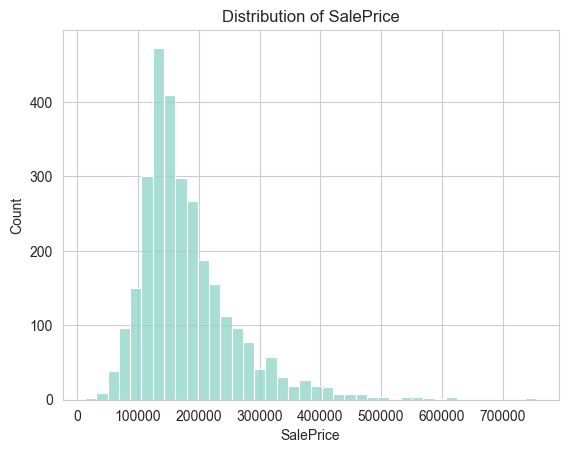

In [181]:
plt.figure()
sns.histplot(ames['SalePrice'], bins=40)
plt.title("Distribution of SalePrice")
plt.show()

## 4. Covariance

Covariance measures how two variables **vary together**.

Definition:

Cov(X,Y) = E[(X − μx)(Y − μy)]

Example: covariance between **living area** and **sale price**.

In [85]:
ames['Gr Liv Area'].cov(ames['SalePrice'])

np.float64(28542199.568276502)

Covariance is difficult to interpret because it depends on **units**.

This motivates **correlation**, a normalized measure.

## 5. Pearson Correlation

Pearson correlation measures **linear relationships**.

Range: -1 to 1

Pearson correlation: 1.00


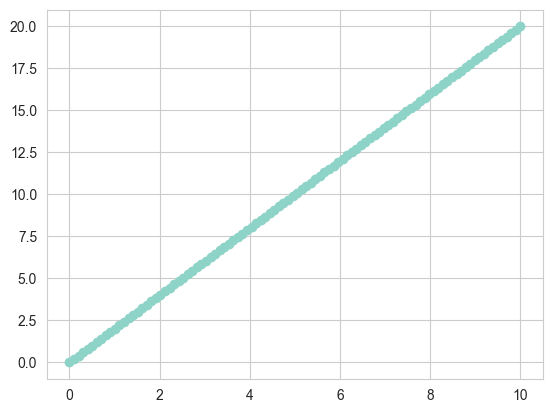

In [182]:
# Criando dados sintéticos onde y = 2x
X = np.linspace(0,10,100)
Y = 2*X

# Calculando a correlação de Pearson
corr_pearson = np.corrcoef(X,Y)[0,1]
print(f"Pearson correlation: {corr_pearson:.2f}")

#plot dos dados
plt.figure()
plt.scatter(X,Y)
plt.show()

Pearson correlation with noise: 0.91


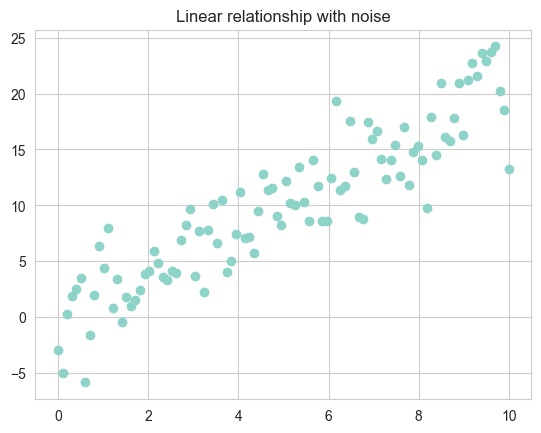

In [183]:
#criando dados sintéticos onde y = 2x + ruido
Y_ruido = 2*X + np.random.normal(0,3,size=X.shape)

# Calculando a correlação de Pearson
corr_pearson_ruido = np.corrcoef(X,Y_ruido)[0,1]
print(f"Pearson correlation with noise: {corr_pearson_ruido:.2f}")

#plot dos dados
plt.figure()
plt.scatter(X,Y_ruido)
plt.title("Linear relationship with noise")
plt.show()

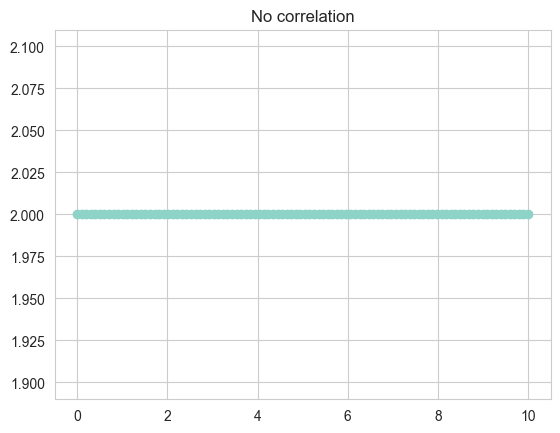

Pearson correlation with no correlation: nan


/Users/zuilpirola/Documents/03_teaching/AED/EDA/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/zuilpirola/Documents/03_teaching/AED/EDA/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [184]:
#criando dados sintéticos onde y = 0x + 2
x = np.linspace(0,10,100)
y = 2 + np.random.normal(0,0.0,size=x.shape)

#plotando os dados
plt.figure()
plt.scatter(x,y)
plt.title("No correlation")
plt.show()

# Calculando a correlação de Pearson
corr_pearson_no_corr = np.corrcoef(x,y)[0,1]
print(f"Pearson correlation with no correlation: {corr_pearson_no_corr:.2f}")

In [185]:
corr = ames.corr(numeric_only=True)
corr.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.173593,0.011797,-0.007034,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,...,-0.011292,0.016355,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408
PID,0.173593,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,...,-0.051135,-0.071311,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521
MS SubClass,0.011797,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,...,-0.017310,-0.014823,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092
Lot Frontage,-0.007034,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,...,0.120084,0.163040,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318
Lot Area,0.031354,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,...,0.157212,0.103760,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549


## 6. Correlation with target variable

In [186]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
corr_target.head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

## 7. Visualizing correlations

Correlation matrices help detect relationships and multicollinearity.

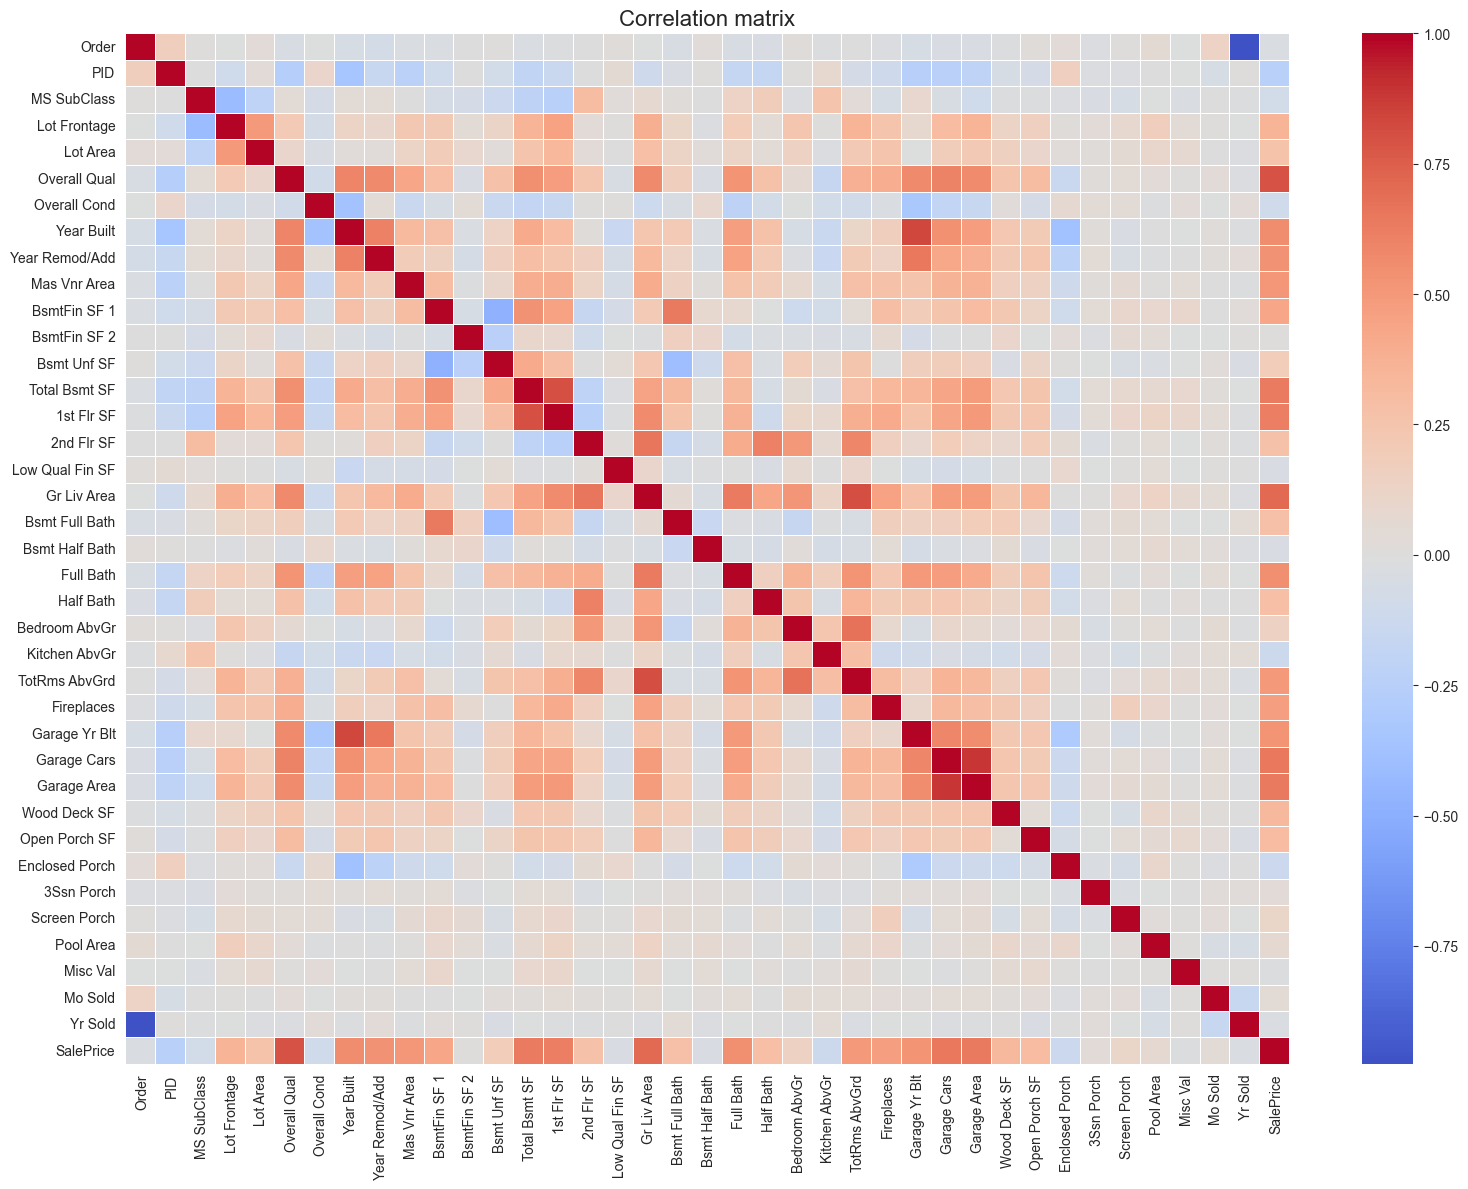

In [187]:
plt.figure(figsize=(16, 12))  # aumenta o tamanho da figura

ax = sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,        # opcional (True se quiser valores)
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation matrix", fontsize=16)

# Centralizar labels no eixo X
ax.set_xticks(np.arange(len(corr.columns)) + 0.8)
ax.set_xticklabels(corr.columns, rotation=90, ha='right', fontsize=10)

# Centralizar labels no eixo Y
ax.set_yticks(np.arange(len(corr.index)) + 0.5)
ax.set_yticklabels(corr.index, rotation=0, fontsize=10)

plt.tight_layout()  # evita cortar labels
plt.show()

## 8. Scatterplots — Always inspect visually

Correlation coefficients should **never be interpreted without visualization**.

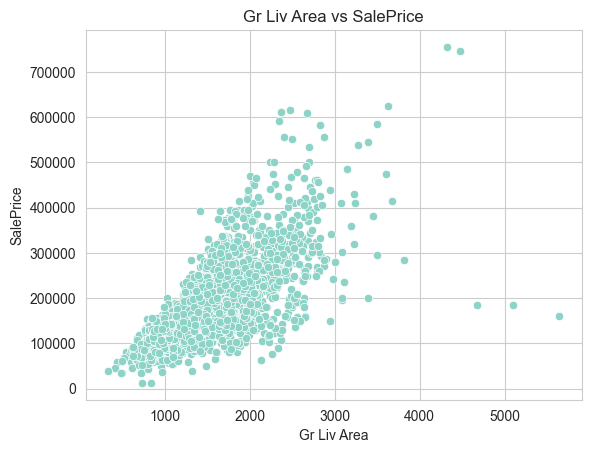

In [188]:
plt.figure()
sns.scatterplot(data=ames, x='Gr Liv Area', y='SalePrice')
plt.title("Gr Liv Area vs SalePrice")
plt.show()

Try other strong predictors.

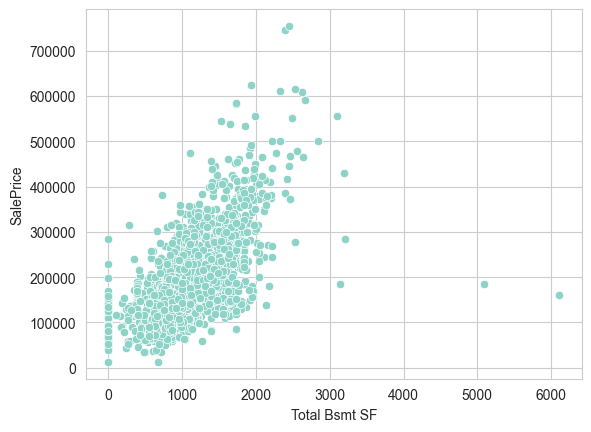

In [189]:
sns.scatterplot(data=ames, x='Total Bsmt SF', y='SalePrice')
plt.show()

## 9. When Pearson Correlation Fails

Pearson measures **linear alignment**, not general relationships.

Example with synthetic nonlinear data.

In [190]:
x = np.linspace(-3,3,200)
y = x**2

round(np.corrcoef(x,y)[0,1])

0

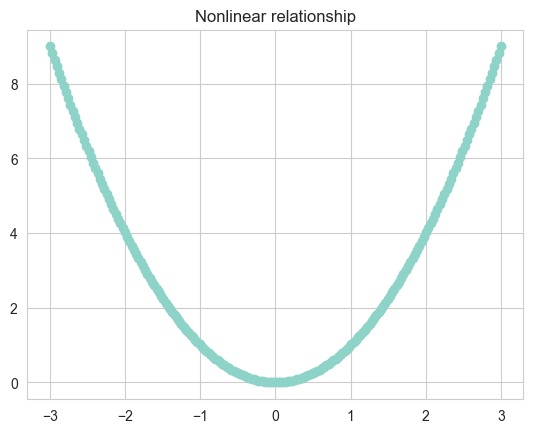

In [191]:
plt.figure()
plt.scatter(x,y)
plt.title("Nonlinear relationship")
plt.show()

## 10. Spearman Correlation

Spearman correlation works with **ranks** and captures monotonic relationships.

In [192]:
ames.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(ascending=False).head(15)

SalePrice         1.000000
Overall Qual      0.808800
Gr Liv Area       0.723342
Garage Cars       0.701813
Year Built        0.680822
Garage Area       0.660676
Garage Yr Blt     0.637674
Full Bath         0.634161
Total Bsmt SF     0.606184
Year Remod/Add    0.601454
1st Flr SF        0.581536
Fireplaces        0.526137
TotRms AbvGrd     0.499253
Open Porch SF     0.479578
Mas Vnr Area      0.442471
Name: SalePrice, dtype: float64

In [193]:
# Criando dados sintéticos onde y = 2x
X = np.linspace(0,10,100)
Y = 2*X

# Calculando a correlação de Spearman
corr_spearman = pd.Series(X).corr(pd.Series(Y), method='spearman')
print(f"Spearman correlation: {corr_spearman:.2f}")

Spearman correlation: 1.00


Pearson correlation: 0.69
Spearman correlation: 1.00


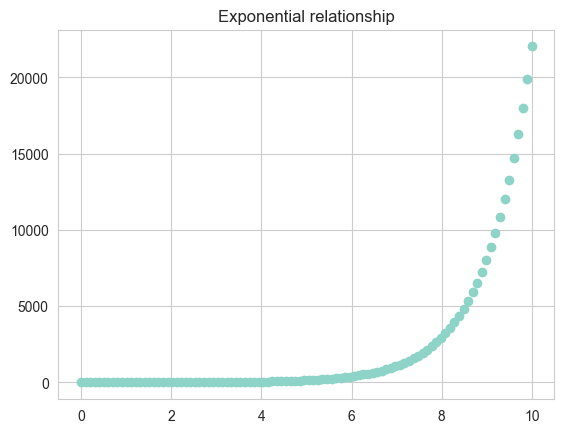

In [194]:
#um pearson baixo e um spearman alto significa que a relação é monotônica mas não linear
#exemplo exponencial
x = np.linspace(0,10,100)
y = np.exp(x)

# Calculando a correlação de Pearson
corr_pearson_exp = np.corrcoef(x,y)[0,1]
print(f"Pearson correlation: {corr_pearson_exp:.2f}")

# Calculando a correlação de Spearman
corr_spearman_exp = pd.Series(x).corr(pd.Series(y), method='spearman')
print(f"Spearman correlation: {corr_spearman_exp:.2f}")

#plot dos dados
plt.figure()
plt.scatter(x,y)
plt.title("Exponential relationship")
plt.show()

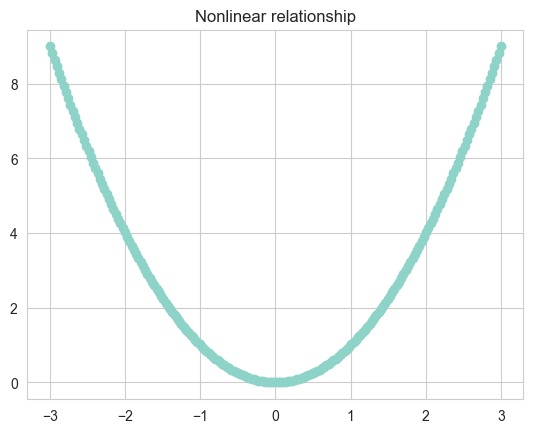

Pearson correlation: -0.00
Spearman correlation: -0.00


In [195]:
# dados sintéticos onde y = xˆ2
x = np.linspace(-3,3,200)
y = x**2

#plot dos dados
plt.figure()
plt.scatter(x,y)
plt.title("Nonlinear relationship")
plt.show()

#calculando a correlação de Pearson
corr_pearson_nonlin = np.corrcoef(x,y)[0,1]
print(f"Pearson correlation: {corr_pearson_nonlin:.2f}")
#calculando a correlação de Spearman
corr_spearman_nonlin = pd.Series(x).corr(pd.Series(y), method='spearman')
print(f"Spearman correlation: {corr_spearman_nonlin:.2f}")

In [196]:


# Distance Correlation
dcor_value = dcor.distance_correlation(x, y)

print("Distance Correlation:", dcor_value)

# 0 → independência
# próximo de 1 → forte dependência (mesmo que não linear)

#usar o grafico e metricas como a distance correlation para identificar relações não lineares é fundamental para evitar interpretações erradas baseadas apenas na correlação de Pearson.

Distance Correlation: 0.491469189407173


## 11. Categorical → Numeric association

Example: `OverallQual` vs `SalePrice`.

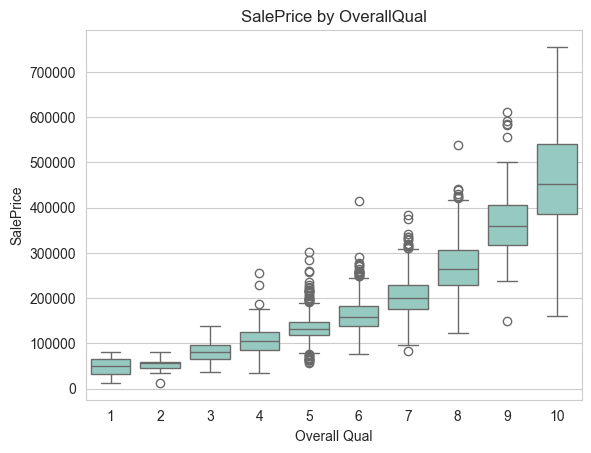

In [197]:
plt.figure()
sns.boxplot(data=ames, x='Overall Qual', y='SalePrice')
plt.title("SalePrice by OverallQual")
plt.show()

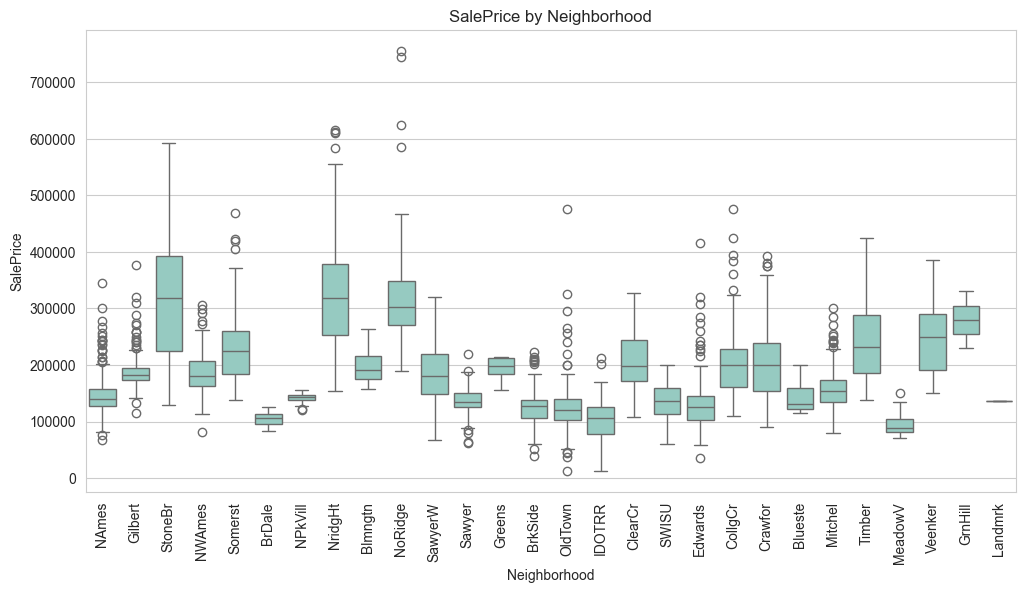

In [198]:
#exemplo no ames de correlação entre SalePrice e Neighborhood
plt.figure(figsize=(12,6))
sns.boxplot(data=ames, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=90)
plt.title("SalePrice by Neighborhood")
plt.show()

## 12. Cross-tabulation and Cramer's V

In [199]:
# Exemplo de cross-tabulation entre Garage Type e House Style
cross_tab = pd.crosstab(ames['Garage Type'], ames['House Style'])
print(cross_tab)

House Style  1.5Fin  1.5Unf  1Story  2.5Fin  2.5Unf  2Story  SFoyer  SLvl
Garage Type                                                              
2Types            1       0      14       0       0       6       1     1
Attchd           68       3    1055       1       2     494      35    73
Basment           4       0      11       1       0       3       8     9
BuiltIn           7       0       2       0       0     143       4    30
CarPort           1       0       9       0       0       4       1     0
Detchd          203      12     316       4      20     191      21    15


In [200]:
# Cálculo do teste qui-quadrado e Cramer's V
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(cross_tab)

n = cross_tab.sum().sum()
k = min(cross_tab.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print("Chi-squared:", chi2)
print("p-value:", p)
print("Cramer's V:", cramers_v)

Chi-squared: 797.6447302837215
p-value: 6.1966826922941524e-145
Cramer's V: 0.2398528113212721


In [201]:
#interpretando os resultados: um p-value baixo indica que há associação entre as variáveis, enquanto o valor de Cramer's V indica a força dessa associação (0.1 = fraca, 0.3 = moderada, 0.5 = forte).

# 13. Multicollinearity

Some predictors measure very similar concepts.

Example: `GarageCars` vs `GarageArea`.

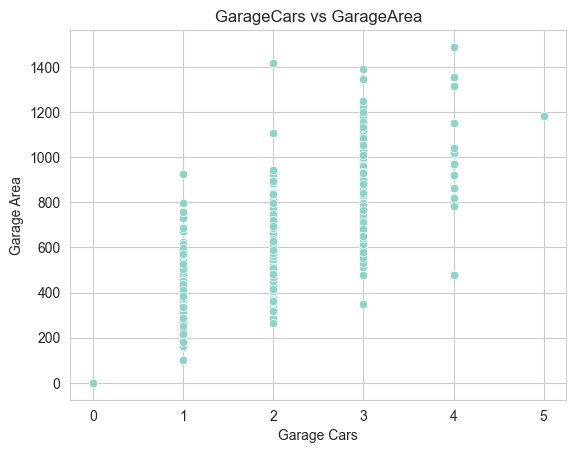

In [202]:
sns.scatterplot(data=ames, x='Garage Cars', y='Garage Area')
plt.title("GarageCars vs GarageArea")
plt.show()

Highly correlated predictors may cause **unstable regression coefficients**.

In [203]:
variables = ['Garage Cars', 'Garage Area']

X = ames[variables].dropna()

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)


      variable       VIF
0        const  6.481825
1  Garage Cars  4.796713
2  Garage Area  4.796713


In [204]:
#conversao de VIF
# VIF = 1 → sem correlação com outras variáveis
# 1 < VIF < 5 → correlação moderada (geralmente aceitável)
# VIF ≥ 5 → alta multicolinearidade (atenção)
# VIF ≥ 10 → problema sério